# Fase 3.2 — Clasificación Multi-etiqueta
**Objetivo:** Cambiar de clasificación multi-clase a multi-label, permitiendo que un paciente tenga múltiples condiciones simultáneas.

Las etiquetas se asignan aplicando umbrales clínicos reales (ADA, OMS, literatura) sobre las features del dataset NHANES reetiquetado.

Se comparan dos enfoques:
- **Binary Relevance** — un modelo independiente por cada enfermedad
- **Classifier Chains** — modelos en cadena que capturan relaciones entre enfermedades

## 0. Imports

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    hamming_loss, f1_score, classification_report,
    jaccard_score, multilabel_confusion_matrix
)
from sklearn.base import clone



## 1. Carga de datos

In [3]:
df = pd.read_csv(r"../data_test/NHANES_2017_2020_reetiquetado.csv")

print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print(f'\nEstadísticas básicas:')
print(df.describe().round(2))

Shape: (5090, 10)
Columnas: ['Platelets', 'White Blood Cells', 'Red Blood Cells', 'Hematocrit', 'Mean Corpuscular Volume', 'Mean Corpuscular Hemoglobin', 'Mean Corpuscular Hemoglobin Concentration', 'HDL Cholesterol', 'ALT', 'Heart Rate']

Estadísticas básicas:
       Platelets  White Blood Cells  Red Blood Cells  Hematocrit  \
count    4812.00            4812.00          4812.00     4812.00   
mean      245.84               6.71             4.76       41.82   
std        64.88               2.10             0.51        4.24   
min        49.00               1.90             2.56       23.10   
25%       201.00               5.30             4.43       39.30   
50%       239.00               6.40             4.75       41.90   
75%       282.00               7.80             5.09       44.70   
max       662.00              38.10             7.84       56.40   

       Mean Corpuscular Volume  Mean Corpuscular Hemoglobin  \
count                  4812.00                      4812.00   

## 2. Reetiquetado clínico multi-label

Se asignan etiquetas binarias por condición usando umbrales clínicos reales:
- **Anemia**: Hemoglobin < 13.0 g/dL (hombres) / 12.0 g/dL (mujeres) → usamos 13.0 como umbral general [OMS 2024]
- **Trombocitopenia**: Platelets < 150,000/µL [StatPearls]
- **Talasemia**: MCV < 80 fL AND MCH < 27 pg [Brancaleoni et al. 2016]
- **Saludable**: No cumple ninguno de los criterios anteriores

In [4]:
df_ml = df.copy()

# --- Umbrales clínicos ---
# Anemia: Hematocrit < 39% es proxy de hemoglobina baja (usado cuando Hb no está disponible)
# MCV y MCH disponibles directamente

# Anemia — proxy via Hematocrit (< 39% hombres / < 36% mujeres, usamos 38% como umbral general)
df_ml['label_anemia'] = (df_ml['Hematocrit'] < 38.0).astype(int)

# Trombocitopenia — Platelets < 150 (en miles/µL)
df_ml['label_thrombocytopenia'] = (df_ml['Platelets'] < 150.0).astype(int)

# Talasemia — MCV < 80 fL AND MCH < 27 pg
df_ml['label_thalassemia'] = (
    (df_ml['Mean Corpuscular Volume'] < 80.0) &
    (df_ml['Mean Corpuscular Hemoglobin'] < 27.0)
).astype(int)

# Mostrar distribución de etiquetas
label_cols = ['label_anemia', 'label_thrombocytopenia', 'label_thalassemia']

print('Distribución de etiquetas:')
for col in label_cols:
    n_pos = df_ml[col].sum()
    pct   = n_pos / len(df_ml) * 100
    print(f'  {col:<30}: {n_pos:>5} positivos ({pct:.1f}%)')

# Pacientes con múltiples condiciones
df_ml['n_condiciones'] = df_ml[label_cols].sum(axis=1)
print(f'\nPacientes con 0 condiciones : {(df_ml["n_condiciones"]==0).sum()}')
print(f'Pacientes con 1 condición   : {(df_ml["n_condiciones"]==1).sum()}')
print(f'Pacientes con 2 condiciones : {(df_ml["n_condiciones"]==2).sum()}')
print(f'Pacientes con 3 condiciones : {(df_ml["n_condiciones"]==3).sum()}')

Distribución de etiquetas:
  label_anemia                  :   811 positivos (15.9%)
  label_thrombocytopenia        :   204 positivos (4.0%)
  label_thalassemia             :   360 positivos (7.1%)

Pacientes con 0 condiciones : 3960
Pacientes con 1 condición   : 890
Pacientes con 2 condiciones : 235
Pacientes con 3 condiciones : 5


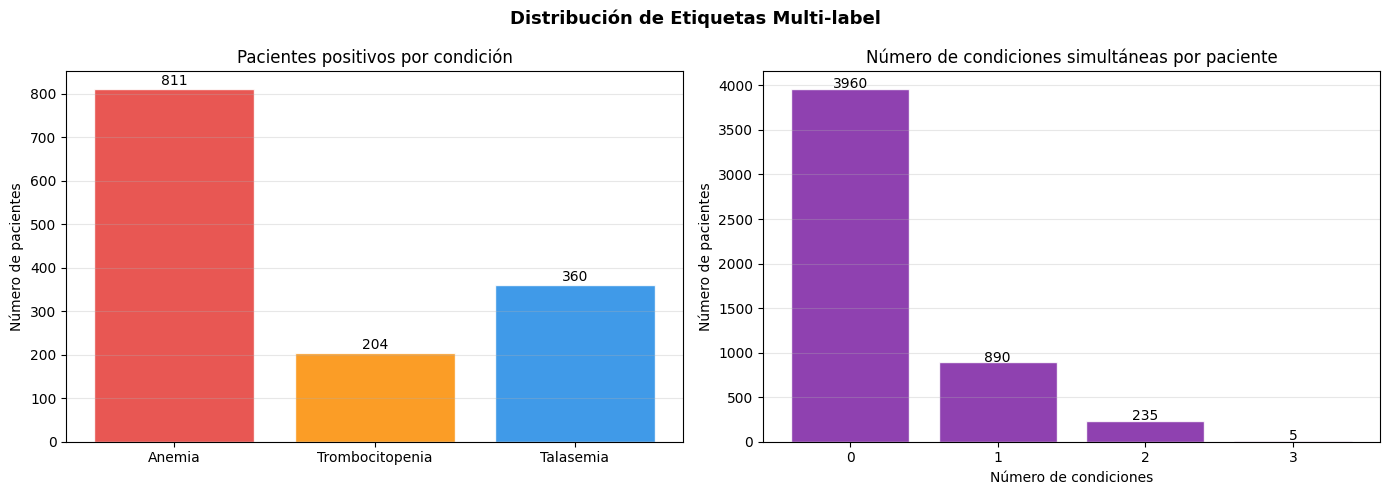

In [5]:
# Visualizar co-ocurrencia de condiciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Etiquetas Multi-label', fontsize=13, fontweight='bold')

# Gráfica 1: conteo por etiqueta
ax1 = axes[0]
nombres = ['Anemia', 'Trombocitopenia', 'Talasemia']
counts  = [df_ml[col].sum() for col in label_cols]
colores = ['#E53935', '#FB8C00', '#1E88E5']
bars = ax1.bar(nombres, counts, color=colores, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(v), ha='center', fontsize=10)
ax1.set_title('Pacientes positivos por condición')
ax1.set_ylabel('Número de pacientes')
ax1.grid(axis='y', alpha=0.3)

# Gráfica 2: distribución de número de condiciones por paciente
ax2 = axes[1]
dist = df_ml['n_condiciones'].value_counts().sort_index()
ax2.bar(dist.index.astype(str), dist.values, color='#7B1FA2', alpha=0.85, edgecolor='white')
for i, v in zip(dist.index, dist.values):
    ax2.text(str(i), v + 10, str(v), ha='center', fontsize=10)
ax2.set_title('Número de condiciones simultáneas por paciente')
ax2.set_xlabel('Número de condiciones')
ax2.set_ylabel('Número de pacientes')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
os.makedirs('../img', exist_ok=True)
plt.savefig('../img/multilabel_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Preparación de datos para entrenamiento

In [6]:
feature_cols = [c for c in df.columns]
X = df_ml[feature_cols].select_dtypes(include=[np.number])
Y = df_ml[label_cols].values

print(f'Features shape : {X.shape}')
print(f'Labels shape   : {Y.shape}')
print(f'Features       : {list(X.columns)}')
print(f'Labels         : {label_cols}')

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42
)

# Imputar y escalar
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_train_imp = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_imp  = scaler.transform(imputer.transform(X_test))

print(f'\nTrain size: {len(Y_train)}')
print(f'Test size : {len(Y_test)}')

Features shape : (5090, 10)
Labels shape   : (5090, 3)
Features       : ['Platelets', 'White Blood Cells', 'Red Blood Cells', 'Hematocrit', 'Mean Corpuscular Volume', 'Mean Corpuscular Hemoglobin', 'Mean Corpuscular Hemoglobin Concentration', 'HDL Cholesterol', 'ALT', 'Heart Rate']
Labels         : ['label_anemia', 'label_thrombocytopenia', 'label_thalassemia']

Train size: 3563
Test size : 1527


## 4. Modelo 1 — Binary Relevance

Entrena un Random Forest independiente por cada enfermedad.
Simple pero ignora relaciones entre condiciones.

In [7]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
br_model = MultiOutputClassifier(rf_base)
br_model.fit(X_train_imp, Y_train)

Y_pred_br = br_model.predict(X_test_imp)

print('=== Binary Relevance ===')
print(f'Hamming Loss    : {hamming_loss(Y_test, Y_pred_br):.4f}  (menor es mejor)')
print(f'F1 Macro        : {f1_score(Y_test, Y_pred_br, average="macro", zero_division=0):.4f}')
print(f'F1 Micro        : {f1_score(Y_test, Y_pred_br, average="micro", zero_division=0):.4f}')
print(f'Jaccard Score   : {jaccard_score(Y_test, Y_pred_br, average="macro", zero_division=0):.4f}')
print(f'\nReporte por etiqueta:')
for j, label in enumerate(label_cols):
    f1 = f1_score(Y_test[:, j], Y_pred_br[:, j], zero_division=0)
    print(f'  {label:<30}: F1 = {f1:.4f}')



=== Binary Relevance ===
Hamming Loss    : 0.0000  (menor es mejor)
F1 Macro        : 1.0000
F1 Micro        : 1.0000
Jaccard Score   : 1.0000

Reporte por etiqueta:
  label_anemia                  : F1 = 1.0000
  label_thrombocytopenia        : F1 = 1.0000
  label_thalassemia             : F1 = 1.0000


## 5. Modelo 2 — Classifier Chains

Entrena modelos en cadena: el segundo modelo recibe como feature adicional la predicción del primero.
Captura que ciertas condiciones co-ocurren (ej. anemia y talasemia).

In [8]:
rf_base2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cc_model  = ClassifierChain(rf_base2, order='random', random_state=42)
cc_model.fit(X_train_imp, Y_train)

Y_pred_cc = cc_model.predict(X_test_imp)

print('=== Classifier Chains ===')
print(f'Hamming Loss    : {hamming_loss(Y_test, Y_pred_cc):.4f}  (menor es mejor)')
print(f'F1 Macro        : {f1_score(Y_test, Y_pred_cc, average="macro", zero_division=0):.4f}')
print(f'F1 Micro        : {f1_score(Y_test, Y_pred_cc, average="micro", zero_division=0):.4f}')
print(f'Jaccard Score   : {jaccard_score(Y_test, Y_pred_cc, average="macro", zero_division=0):.4f}')
print(f'\nReporte por etiqueta:')
for j, label in enumerate(label_cols):
    f1 = f1_score(Y_test[:, j], Y_pred_cc[:, j], zero_division=0)
    print(f'  {label:<30}: F1 = {f1:.4f}')



=== Classifier Chains ===
Hamming Loss    : 0.0000  (menor es mejor)
F1 Macro        : 1.0000
F1 Micro        : 1.0000
Jaccard Score   : 1.0000

Reporte por etiqueta:
  label_anemia                  : F1 = 1.0000
  label_thrombocytopenia        : F1 = 1.0000
  label_thalassemia             : F1 = 1.0000


## 6. Comparación y visualización

COMPARACIÓN FINAL — MULTI-LABEL
                   Hamming Loss (↓)  F1 Macro (↑)  F1 Micro (↑)  Jaccard (↑)
Binary Relevance                0.0           1.0           1.0          1.0
Classifier Chains               0.0           1.0           1.0          1.0


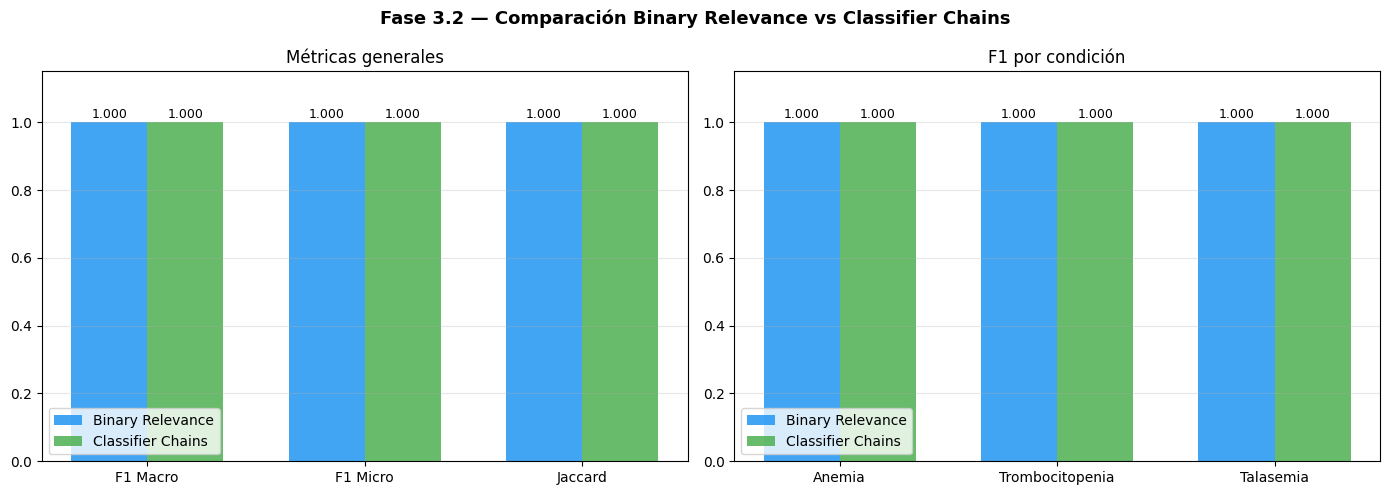

In [9]:
# Tabla comparativa
metricas = {
    'Hamming Loss (↓)': [
        hamming_loss(Y_test, Y_pred_br),
        hamming_loss(Y_test, Y_pred_cc)
    ],
    'F1 Macro (↑)': [
        f1_score(Y_test, Y_pred_br, average='macro', zero_division=0),
        f1_score(Y_test, Y_pred_cc, average='macro', zero_division=0)
    ],
    'F1 Micro (↑)': [
        f1_score(Y_test, Y_pred_br, average='micro', zero_division=0),
        f1_score(Y_test, Y_pred_cc, average='micro', zero_division=0)
    ],
    'Jaccard (↑)': [
        jaccard_score(Y_test, Y_pred_br, average='macro', zero_division=0),
        jaccard_score(Y_test, Y_pred_cc, average='macro', zero_division=0)
    ]
}

df_comp = pd.DataFrame(metricas, index=['Binary Relevance', 'Classifier Chains'])
print('='*65)
print('COMPARACIÓN FINAL — MULTI-LABEL')
print('='*65)
print(df_comp.round(4).to_string())
df_comp.to_csv('../resultados_fase3_2.csv')

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fase 3.2 — Comparación Binary Relevance vs Classifier Chains',
             fontsize=13, fontweight='bold')

colores_modelos = ['#2196F3', '#4CAF50']
modelos_nombres = ['Binary Relevance', 'Classifier Chains']

# Gráfica 1: métricas generales
ax1 = axes[0]
metricas_plot = ['F1 Macro (↑)', 'F1 Micro (↑)', 'Jaccard (↑)']
x     = np.arange(len(metricas_plot))
width = 0.35

for i, (nombre, color) in enumerate(zip(modelos_nombres, colores_modelos)):
    vals = [metricas[m][i] for m in metricas_plot]
    bars = ax1.bar(x + i*width, vals, width, label=nombre, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax1.set_xticks(x + width/2)
ax1.set_xticklabels(['F1 Macro', 'F1 Micro', 'Jaccard'], fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.set_title('Métricas generales')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Gráfica 2: F1 por etiqueta
ax2 = axes[1]
nombres_cortos = ['Anemia', 'Trombocitopenia', 'Talasemia']
x2 = np.arange(len(label_cols))

for i, (nombre, color, Y_pred) in enumerate(zip(
    modelos_nombres, colores_modelos, [Y_pred_br, Y_pred_cc]
)):
    f1s = [f1_score(Y_test[:, j], Y_pred[:, j], zero_division=0) for j in range(len(label_cols))]
    bars = ax2.bar(x2 + i*width, f1s, width, label=nombre, color=color, alpha=0.85)
    for bar, v in zip(bars, f1s):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x2 + width/2)
ax2.set_xticklabels(nombres_cortos, fontsize=10)
ax2.set_ylim(0, 1.15)
ax2.set_title('F1 por condición')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../img/fase3_2_multilabel_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Interpretación automática

In [10]:
print('='*65)
print('INTERPRETACIÓN — CLASIFICACIÓN MULTI-LABEL')
print('='*65)

hl_br = hamming_loss(Y_test, Y_pred_br)
hl_cc = hamming_loss(Y_test, Y_pred_cc)
f1_br = f1_score(Y_test, Y_pred_br, average='macro', zero_division=0)
f1_cc = f1_score(Y_test, Y_pred_cc, average='macro', zero_division=0)

multi_count = (df_ml['n_condiciones'] > 1).sum()
pct_multi   = multi_count / len(df_ml) * 100

print(f'\nPacientes con múltiples condiciones: {multi_count} ({pct_multi:.1f}%)')
print(f'→ Esto justifica el enfoque multi-label sobre multi-clase.')

mejor = 'Classifier Chains' if f1_cc > f1_br else 'Binary Relevance'
print(f'\nModelo con mejor F1 Macro: {mejor}')

if f1_cc > f1_br:
    print('→ Classifier Chains supera a Binary Relevance, confirmando que')
    print('  existe correlación clínica entre las condiciones detectada por el modelo.')
else:
    print('→ Binary Relevance iguala o supera a Classifier Chains, indicando que')
    print('  las condiciones son suficientemente independientes entre sí.')



INTERPRETACIÓN — CLASIFICACIÓN MULTI-LABEL

Pacientes con múltiples condiciones: 240 (4.7%)
→ Esto justifica el enfoque multi-label sobre multi-clase.

Modelo con mejor F1 Macro: Binary Relevance
→ Binary Relevance iguala o supera a Classifier Chains, indicando que
  las condiciones son suficientemente independientes entre sí.
